# CNN attribution on synthetic bars

Train a tiny CNN from scratch on 16×16 horizontal/vertical bars. The held-out seed differs from training. Signed input derivatives measure local score sensitivity; Grad-CAM is a normalized coarse class-localization map, not a segmentation or causal explanation. Reference: [Selvaraju et al., Grad-CAM (2017)](https://arxiv.org/abs/1610.02391).

Offline CPU tutorial. Fixed seeds and two PyTorch threads; small synthetic data only.


In [1]:
import os, sys, time, resource, json
from pathlib import Path
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
root = Path.cwd()
if not (root / "src").is_dir():
    root = root.parent
sys.path.insert(0, str(root / "src"))
import numpy as np
import torch
from torch import nn
torch.set_num_threads(2)
torch.set_num_interop_threads(2)
torch.manual_seed(7)
np.random.seed(7)
started = time.perf_counter()
print("CPU only; torch", torch.__version__, "threads", torch.get_num_threads())



CPU only; torch 2.10.0.dev20251025+cpu threads 2


Held-out accuracy: 1.0
Signed gradient range: -0.2814200818538666 0.3055291473865509
Grad-CAM shape/range: (2, 16, 16) 0.0 1.0


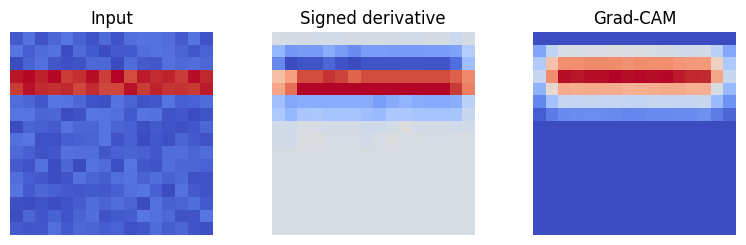

In [2]:
from autoexplain.demo import trained_demo, bars
from autoexplain.core import Inspector
model = trained_demo(steps=40)
images, labels = bars(32, seed=99)
inspector = Inspector(model)
with torch.no_grad():
    scores = model(images)
print("Held-out accuracy:", (scores.argmax(1) == labels).float().mean().item())
gradients = inspector.input_gradients(images[:2], target=labels[:2])
cam = inspector.gradcam(images[:2], layer="features.2", target=labels[:2])
assert gradients.shape == (2, 1, 16, 16)
assert cam.shape == (2, 16, 16) and torch.isfinite(cam).all()
print("Signed gradient range:", gradients.min().item(), gradients.max().item())
print("Grad-CAM shape/range:", tuple(cam.shape), cam.min().item(), cam.max().item())
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(8, 2.5))
for ax, data, title in zip(axes, [images[0, 0], gradients[0, 0], cam[0]],
                          ["Input", "Signed derivative", "Grad-CAM"]):
    ax.imshow(data, cmap="coolwarm")
    ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()



In [3]:
elapsed = time.perf_counter() - started
rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
# Linux reports KiB; macOS reports bytes. This is this kernel's lifetime high-water mark.
peak_mib = rss / (1024 * 1024 if sys.platform == "darwin" else 1024)
print(json.dumps({"tutorial_compute_wall_seconds": round(elapsed, 3),
                  "kernel_lifetime_peak_rss_mib": round(peak_mib, 2),
                  "memory_scope": "kernel process only; includes imports; excludes child processes"}))



{"tutorial_compute_wall_seconds": 0.921, "kernel_lifetime_peak_rss_mib": 402.79, "memory_scope": "kernel process only; includes imports; excludes child processes"}
